In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Задача 1

In [16]:
def plot_benchmarks(filename):
    df = pd.read_csv(filename)

    plt.figure(figsize=(12, 6))
    for block in df['BlockSize'].unique():
        subset = df[df['BlockSize'] == block]
        plt.plot(subset['N'], subset['TimeMs'], marker='o', label=f'Block {block}')
    plt.xlabel('Размер вектора (N)')
    plt.ylabel('Время (мс)')
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title('Зависимость времени от размера вектора')
    plt.legend()
    plt.grid(True)
    plt.show()

    fixed_N = 2097152
    subset_fixed = df[df['N'] == fixed_N]
    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed['BlockSize'], subset_fixed['TimeMs'], marker='s')
    plt.xlabel('Размер блока')
    plt.ylabel('Время (мс)')
    plt.title(f'Зависимость времени от размера блока ($N=2^{{21}}$)')
    plt.grid(True)
    plt.show()

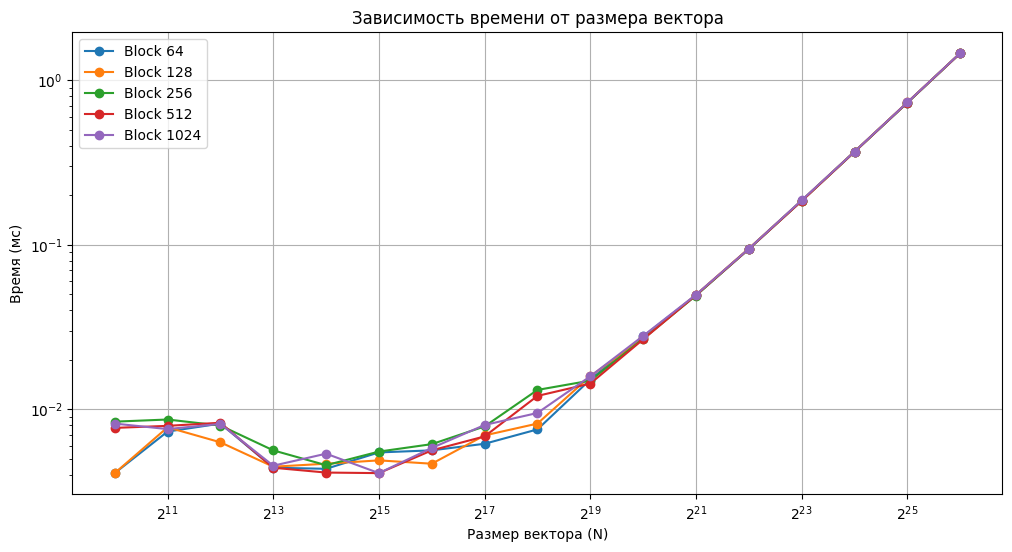

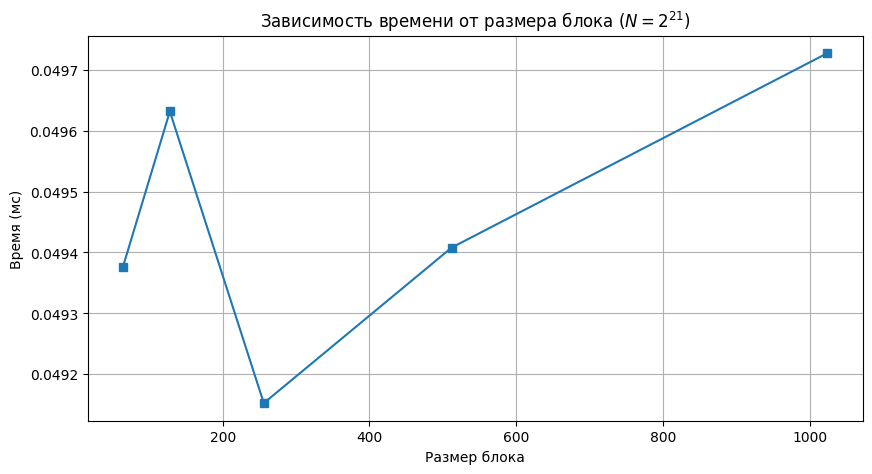

In [19]:
plot_benchmarks('benchmark_task1.csv')

# Задача 2

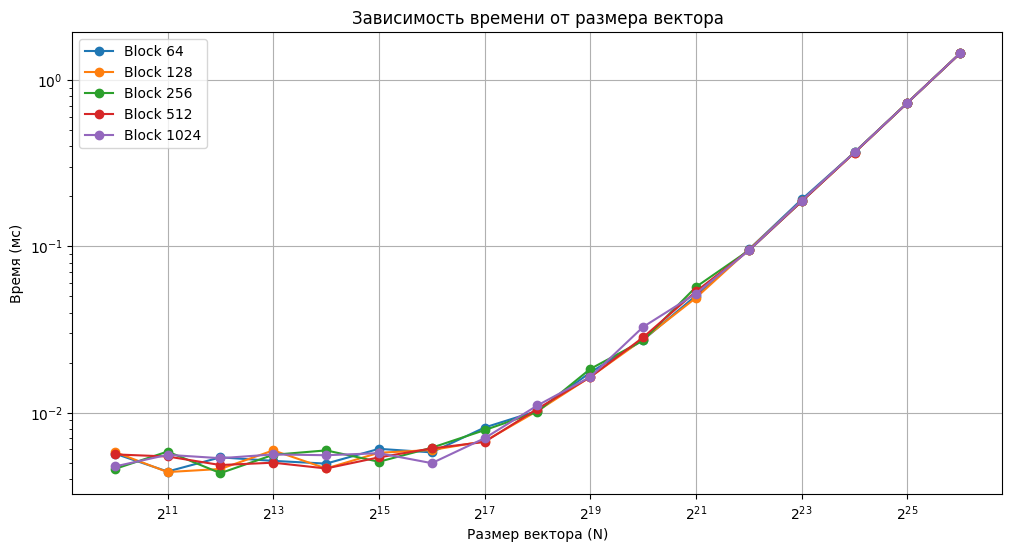

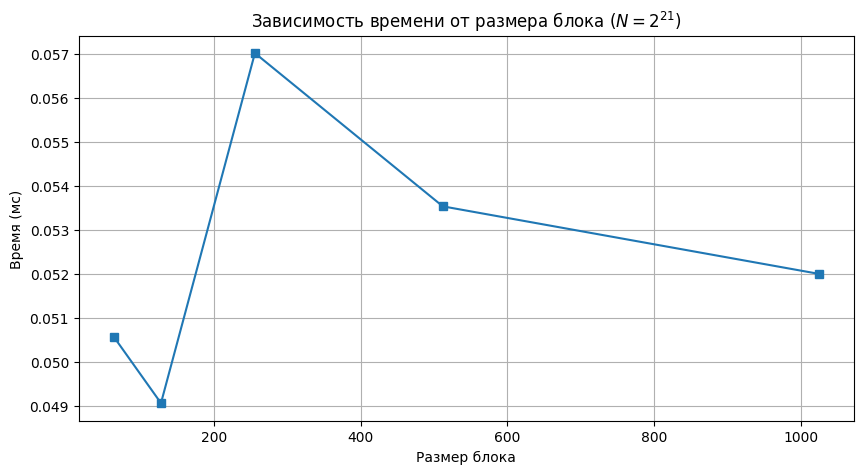

In [15]:
plot_benchmarks('benchmark_task_mul.csv')

# Задача 3

In [25]:
def plot_benchmarks_matrix(filename):
    df = pd.read_csv(filename)

    df['MatrixSize'] = df['Height'] * df['Width']
    df['BlockSizeLabel'] = df['BlockX'].astype(str) + 'x' + df['BlockY'].astype(str)

    plt.figure(figsize=(12, 6))
    for block in df['BlockSizeLabel'].unique():
        subset = df[df['BlockSizeLabel'] == block].sort_values('MatrixSize')
        plt.plot(subset['MatrixSize'], subset['TimeMs'], marker='o', label=f'Block {block}')

    plt.xlabel('Размер матрицы (Height × Width)')
    plt.ylabel('Время (мс)')
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title('Зависимость времени от размера матрицы')
    plt.legend()
    plt.grid(True)
    plt.savefig('matrix_add_time_vs_matrix_size.png')
    plt.show()

    max_size_row = df.loc[df['MatrixSize'].idxmax()]
    fixed_height = max_size_row['Height']
    fixed_width = max_size_row['Width']

    subset_fixed = df[(df['Height'] == fixed_height) & (df['Width'] == fixed_width)].copy()
    subset_fixed['ThreadsPerBlock'] = subset_fixed['BlockX'] * subset_fixed['BlockY']
    subset_fixed = subset_fixed.sort_values('ThreadsPerBlock')

    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed['BlockSizeLabel'], subset_fixed['TimeMs'], marker='s')
    plt.xlabel('Размер блока')
    plt.ylabel('Время (мс)')
    plt.title(f'Зависимость времени от размера блока ({fixed_height}×{fixed_width})')
    plt.grid(True)
    plt.savefig('matrix_add_time_vs_block_size.png')
    plt.show()

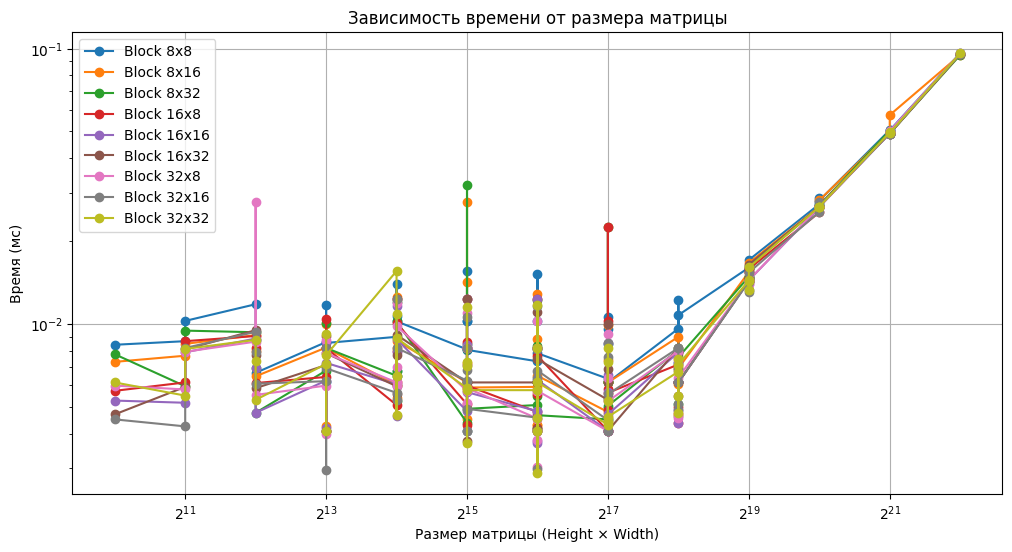

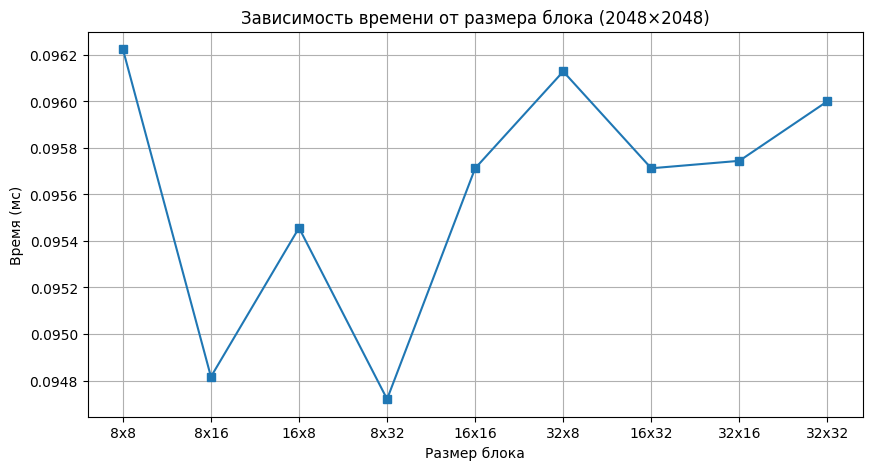

In [30]:
plot_benchmarks_matrix('benchmark_task_matrix_add.csv')

In [ ]:
def plot_block_heatmap(filename):
    df = pd.read_csv(filename)

    df["Elements"] = df["Height"] * df["Width"]

    max_row = df.loc[df["Elements"].idxmax()]
    fixed_height = max_row["Height"]
    fixed_width = max_row["Width"]

    subset = df[(df["Height"] == fixed_height) & (df["Width"] == fixed_width)].copy()

    heatmap_data = subset.pivot_table(
        index="BlockY",
        columns="BlockX",
        values="TimeMs",
        aggfunc="mean"
    )

    heatmap_data = heatmap_data.sort_index().sort_index(axis=1)

    plt.figure(figsize=(7, 6))
    plt.imshow(heatmap_data, aspect='auto')
    plt.colorbar(label="Время (мс)")

    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

    plt.xlabel("BlockX")
    plt.ylabel("BlockY")
    plt.title(f"Heatmap времени для матрицы {fixed_height}x{fixed_width}")

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{value:.4f}", ha="center", va="center")

    plt.show()

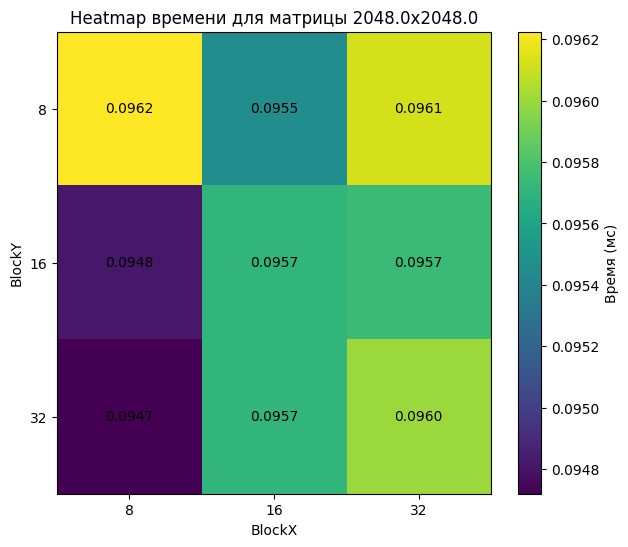

In [29]:
plot_block_heatmap('benchmark_task_matrix_add.csv')

# Задача 4

In [36]:
def plot_benchmarks_4(filename):
    df = pd.read_csv(filename)

    df["Elements"] = df["Height"] * df["Width"]

    plt.figure(figsize=(12, 6))
    for block in sorted(df["BlockSize"].unique()):
        subset = df[df["BlockSize"] == block].copy()
        subset = subset.sort_values("Elements")
        subset = subset.groupby("Elements")["TimeMs"].mean().reset_index()

        plt.plot(subset["Elements"], subset["TimeMs"], marker='o', label=f'Block {block}')

    plt.xlabel('Количество элементов в матрице')
    plt.ylabel('Время (мс)')
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title('Зависимость времени умножения матрицы на вектор от размера матрицы')
    plt.legend()
    plt.grid(True)
    plt.savefig('matrix_vector_mul_time_vs_size.png')
    plt.show()

    max_row = df.loc[df["Elements"].idxmax()]
    fixed_height = max_row["Height"]
    fixed_width = max_row["Width"]

    subset_fixed = df[(df["Height"] == fixed_height) & (df["Width"] == fixed_width)].copy()
    subset_fixed = subset_fixed.sort_values("BlockSize")

    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed["BlockSize"], subset_fixed["TimeMs"], marker='s')
    plt.xlabel('Размер блока')
    plt.ylabel('Время (мс)')
    plt.title(f'Зависимость времени от размера блока ({fixed_height}x{fixed_width})')
    plt.grid(True)
    plt.show()

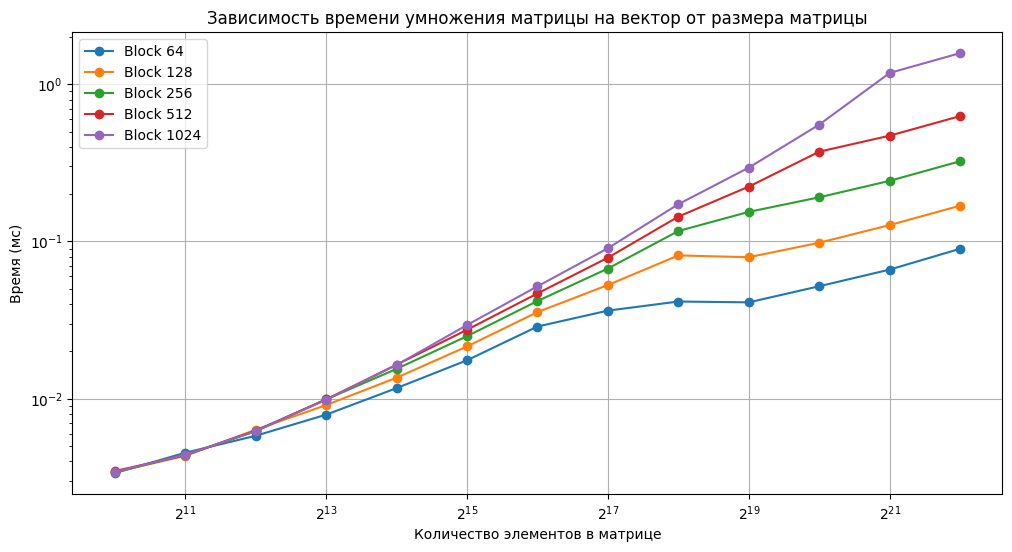

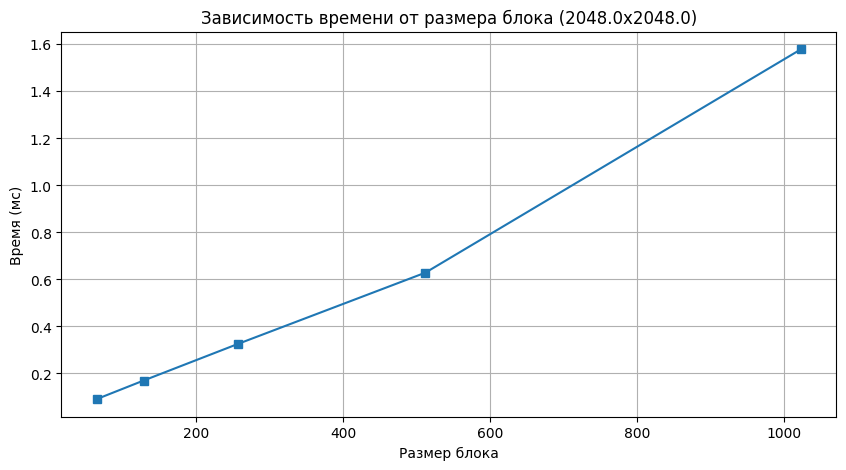

In [37]:
plot_benchmarks_4('benchmark_task_matrix_vector_mul.csv')

# Задача 5

In [9]:
def plot_benchmarks5(filename):
    df = pd.read_csv(filename)

    plt.figure(figsize=(12, 6))
    for block in sorted(df['BlockSize'].unique()):
        subset = df[df['BlockSize'] == block].copy()
        subset = subset.sort_values('N')
        plt.plot(subset['N'], subset['TimeMs'], marker='o', label=f'Block {block}')

    plt.xlabel('Размер вектора (N)')
    plt.ylabel('Время (мс)')
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title('Зависимость времени вычисления скалярного произведения от размера вектора')
    plt.legend()
    plt.grid(True)
    plt.savefig('scalar_mul_time_vs_vector_size.png')
    plt.show()

    fixed_N = df['N'].max()
    subset_fixed = df[df['N'] == fixed_N].copy()
    subset_fixed = subset_fixed.sort_values('BlockSize')

    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed['BlockSize'], subset_fixed['TimeMs'], marker='s')
    plt.xlabel('Размер блока')
    plt.ylabel('Время (мс)')
    plt.title(f'Зависимость времени от размера блока (N={fixed_N})')
    plt.grid(True)
    plt.show()

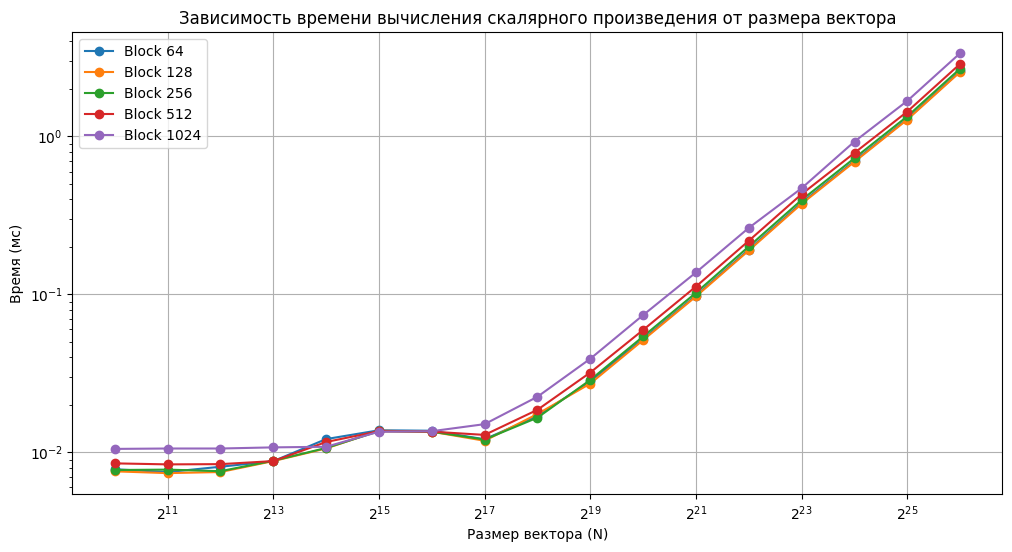

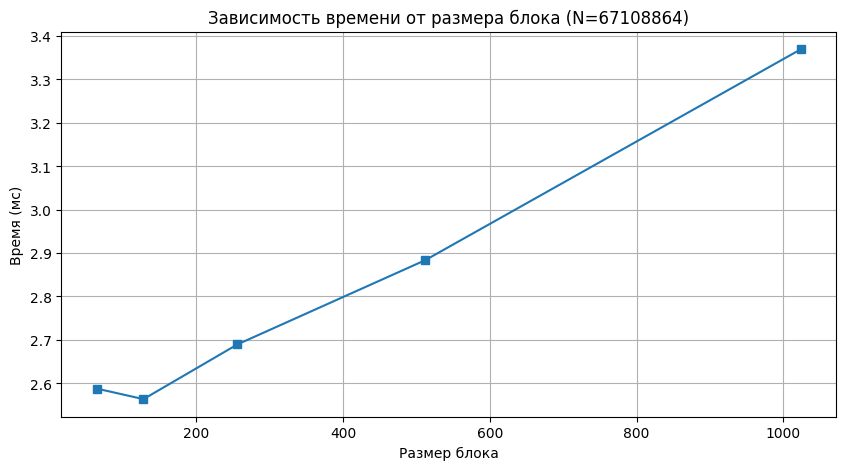

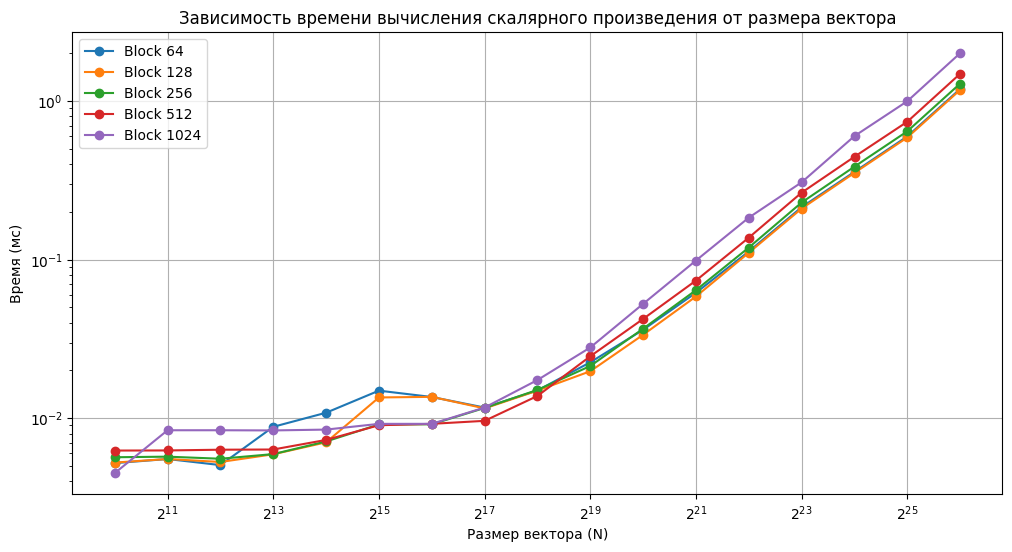

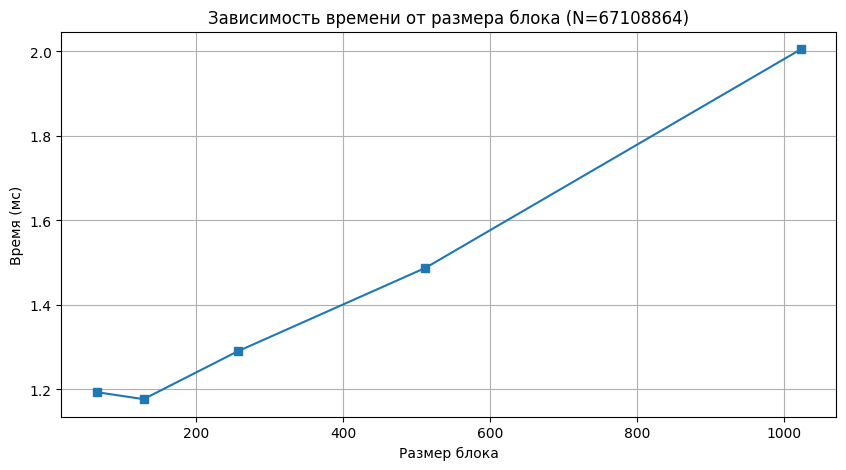

In [10]:
plot_benchmarks5("benchmark_scalar_mul_two_reductions.csv")
plot_benchmarks5("benchmark_scalar_mul_sum_plus_reduction.csv")

# Задача 6

In [5]:
def plot_benchmarks6(filename):
    df = pd.read_csv(filename)

    plt.figure(figsize=(12, 6))
    for block in sorted(df['BlockSize'].unique()):
        subset = df[df['BlockSize'] == block].copy()
        subset = subset.sort_values('N')
        plt.plot(subset['N'], subset['TimeMs'], marker='o', label=f'Block {block}')

    plt.xlabel('Размер вектора (N)')
    plt.ylabel('Время (мс)')
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title('Зависимость времени вычисления косинуса между векторами от размера вектора')
    plt.legend()
    plt.grid(True)
    plt.savefig('cosine_vector_time_vs_vector_size.png')
    plt.show()

    fixed_N = df['N'].max()
    subset_fixed = df[df['N'] == fixed_N].copy()
    subset_fixed = subset_fixed.sort_values('BlockSize')

    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed['BlockSize'], subset_fixed['TimeMs'], marker='s')
    plt.xlabel('Размер блока')
    plt.ylabel('Время (мс)')
    plt.title(f'Зависимость времени от размера блока (N={fixed_N})')
    plt.grid(True)
    plt.savefig('cosine_vector_time_vs_block_size.png')
    plt.show()

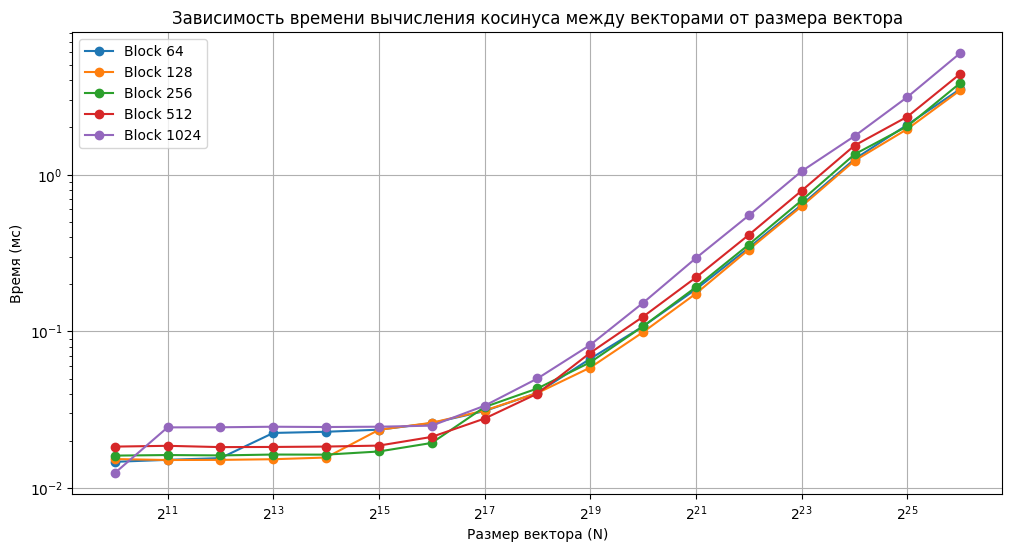

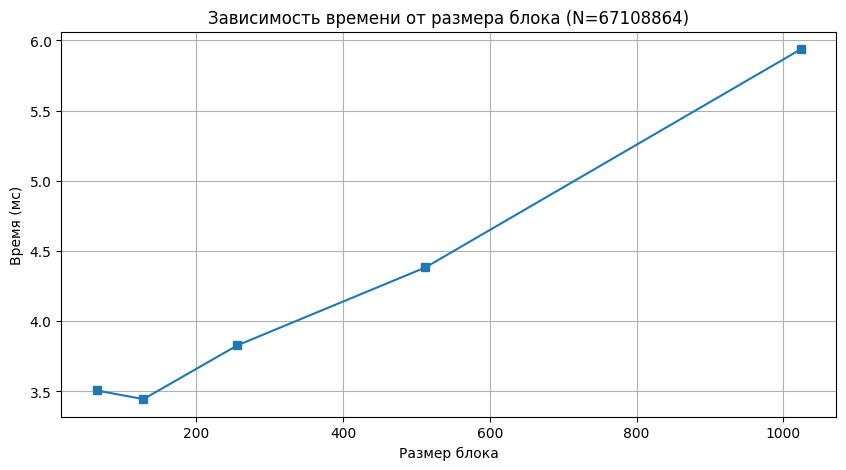

In [11]:
plot_benchmarks6('benchmark_cosine_vector.csv')

# Задача 7

In [14]:
def plot_benchmarks7(filename):
    df = pd.read_csv(filename)

    df["ProblemSize"] = df["HeightA"] * df["WidthA"] * df["WidthB"]

    plt.figure(figsize=(12, 6))
    for block in sorted(df["BlockSize"].unique()):
        subset = df[df["BlockSize"] == block].copy()
        subset = subset.sort_values("ProblemSize")
        subset = subset.groupby("ProblemSize")["TimeMs"].mean().reset_index()

        plt.plot(subset["ProblemSize"], subset["TimeMs"], marker="o", label=f"Block {block}")

    plt.xlabel("Размер задачи (HeightA × WidthA × WidthB)")
    plt.ylabel("Время (мс)")
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.title("Зависимость времени умножения матриц от размера задачи")
    plt.legend()
    plt.grid(True)
    plt.savefig("matrix_mul_time_vs_problem_size.png")
    plt.show()

    max_row = df.loc[df["ProblemSize"].idxmax()]
    fixed_h = max_row["HeightA"]
    fixed_mid = max_row["WidthA"]
    fixed_w = max_row["WidthB"]

    subset_fixed = df[
        (df["HeightA"] == fixed_h) &
        (df["WidthA"] == fixed_mid) &
        (df["WidthB"] == fixed_w)
    ].copy()

    subset_fixed = subset_fixed.sort_values("BlockSize")

    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed["BlockSize"], subset_fixed["TimeMs"], marker="s")
    plt.xlabel("Размер блока")
    plt.ylabel("Время (мс)")
    plt.title(f"Зависимость времени от размера блока ({fixed_h}x{fixed_mid} * {fixed_mid}x{fixed_w})")
    plt.grid(True)
    plt.savefig("matrix_mul_time_vs_block_size.png")
    plt.show()

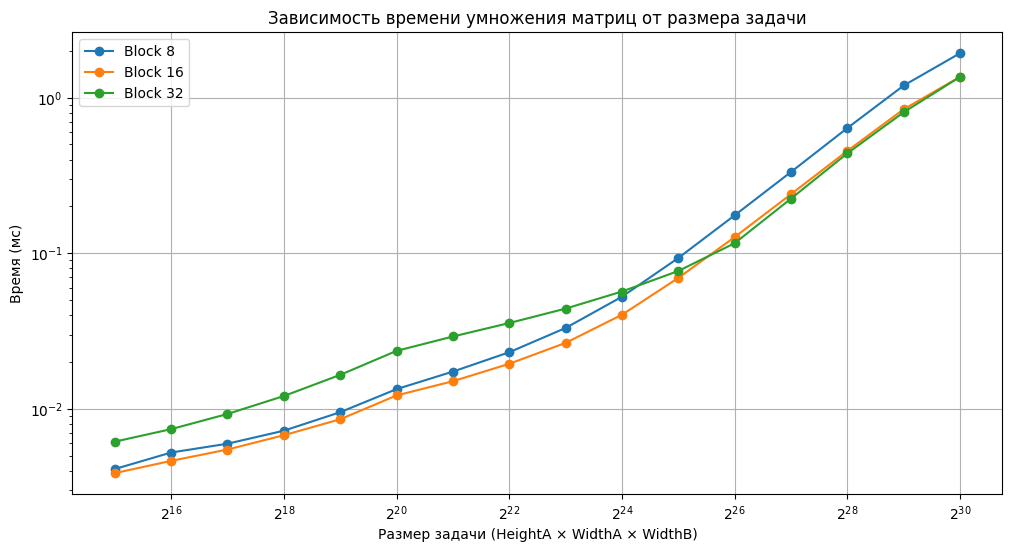

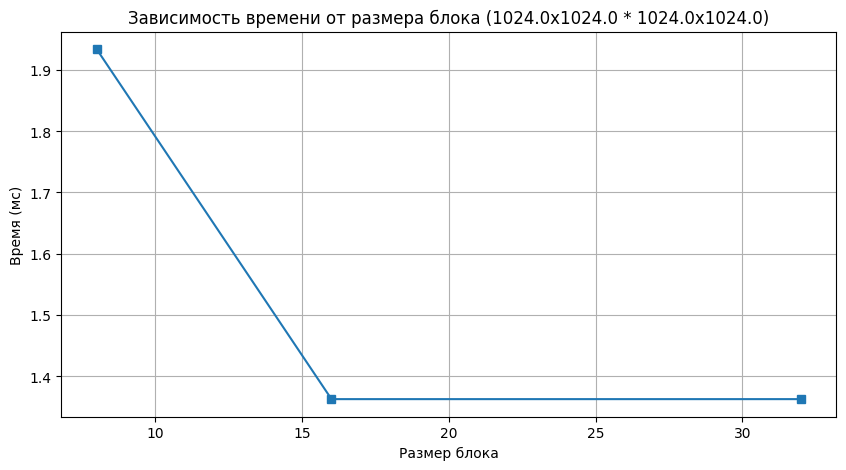

In [15]:
plot_benchmarks7('benchmark_matrix_mul.csv')

# Задача 8

In [17]:
def plot_benchmarks8(filename):
    df = pd.read_csv(filename)

    plt.figure(figsize=(12, 6))
    for block in sorted(df['BlockSize'].unique()):
        subset = df[df['BlockSize'] == block].copy()
        subset = subset.sort_values('N')
        plt.plot(subset['N'], subset['TimeMs'], marker='o', label=f'Block {block}')

    plt.xlabel('Размер массива (N)')
    plt.ylabel('Время (мс)')
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.title('Зависимость времени фильтрации от размера массива')
    plt.legend()
    plt.grid(True)
    plt.savefig('filter_time_vs_array_size.png')
    plt.show()

    fixed_N = df['N'].max()
    subset_fixed = df[df['N'] == fixed_N].copy()
    subset_fixed = subset_fixed.sort_values('BlockSize')

    plt.figure(figsize=(10, 5))
    plt.plot(subset_fixed['BlockSize'], subset_fixed['TimeMs'], marker='s')
    plt.xlabel('Размер блока')
    plt.ylabel('Время (мс)')
    plt.title(f'Зависимость времени фильтрации от размера блока (N={fixed_N})')
    plt.grid(True)
    plt.show()

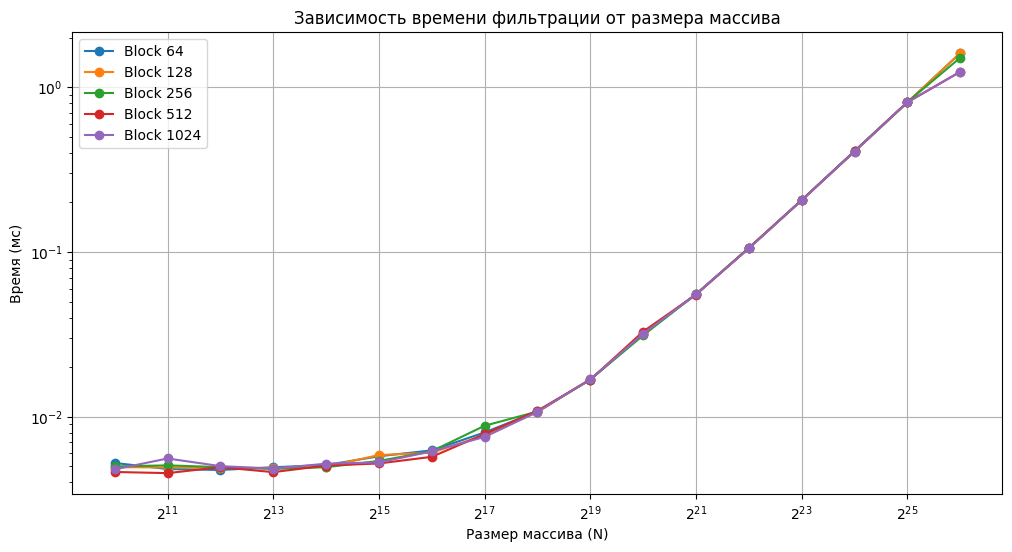

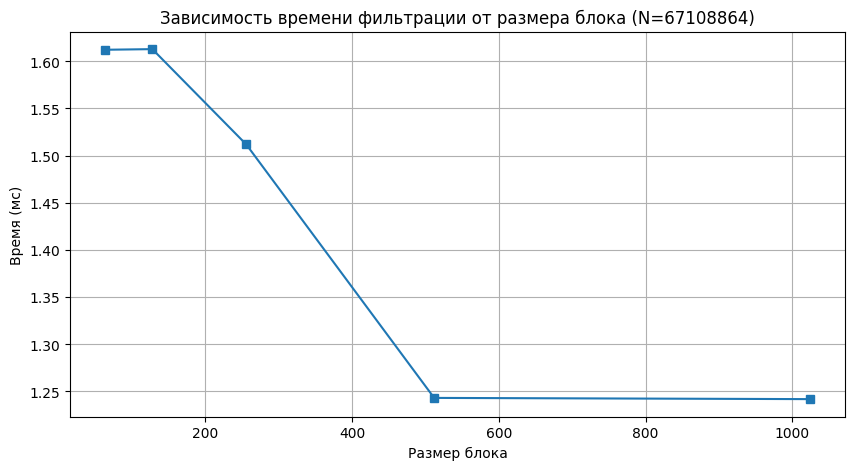

In [18]:
plot_benchmarks8('benchmark_filter.csv')